<a href="https://colab.research.google.com/github/ssk-algoverse/sae-binding/blob/main/circuit/Position14_Bias_Investigation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install transformer_lens

In [31]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import ast
from torch.utils.data import Dataset, DataLoader

In [ ]:
from huggingface_hub import hf_hub_download

REPO_ID = "sebastianhoenig/2L_1H_Entity_Binding"
FILENAME = "2L_1H_Attn_Only.pth"

weights_path = hf_hub_download(repo_id=REPO_ID, filename=FILENAME)

In [4]:
### Model

from transformer_lens import HookedTransformer, HookedTransformerConfig

E = 100 # num entities
A = 100 # num attributes
T = 10 # num types/relations
SEP = E+A+T # as seperator between relations
Q = E+A+T+1 # question token
PAD = E+A+T+2
D_VOCAB = E+A+T+3
IGNORE_INDEX = -100

cfg = HookedTransformerConfig(
    n_layers=2,
    n_heads=1,
    d_model=256,
    d_head=256,
    d_mlp=1024,
    n_ctx=64,
    d_vocab=D_VOCAB,
    act_fn="gelu",
    attn_only=True,
    normalization_type="LN",
)
model = HookedTransformer(cfg)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# Load the model
# Create a new model instance with the same configuration
pretrained_weights = torch.load(weights_path, map_location=device, weights_only=True)
model.load_state_dict(pretrained_weights)

print("Model loaded successfully.")

Moving model to device:  cuda
Model loaded successfully.


In [6]:
id_mapping_df = pd.read_csv('id_mapping.csv')
id_to_entity = dict(zip(id_mapping_df['id'], id_mapping_df['name']))

In [7]:
class EntityBindingDataset(Dataset):
    def __init__(self, dataframe, parse_tokens_if_str=True):
        self.df = dataframe.reset_index(drop=True)
        self.parse_tokens_if_str = parse_tokens_if_str

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        seq = row["tokens"]
        tokens = torch.tensor(seq, dtype=torch.long)
        label  = torch.tensor(int(row["label"]), dtype=torch.long)
        return tokens, label

test_df = pd.read_csv('test_df.csv', converters={"tokens": ast.literal_eval})
test_dataset = EntityBindingDataset(test_df)

In [8]:
val_df = pd.read_csv('val_df.csv', converters={"tokens": ast.literal_eval})
val_dataset = EntityBindingDataset(val_df)

train_df = pd.read_csv('train_df.csv', converters={"tokens": ast.literal_eval})
train_dataset = EntityBindingDataset(train_df)

In [9]:
train_df

,tokens,label
0,"[39, 203, 133, 210, 11, 200, 161, 210, 87, 205...",148
1,"[56, 204, 109, 210, 71, 207, 129, 210, 59, 200...",171
2,"[17, 209, 121, 210, 81, 203, 107, 210, 48, 204...",146
3,"[92, 202, 161, 210, 90, 207, 178, 210, 70, 204...",161
4,"[45, 206, 191, 210, 88, 202, 143, 210, 52, 208...",199
...,...,...
63995,"[66, 206, 114, 210, 84, 202, 189, 210, 1, 203,...",189
63996,"[59, 205, 114, 210, 66, 200, 186, 210, 18, 203...",149
63997,"[70, 205, 131, 210, 33, 206, 186, 210, 0, 204,...",105
63998,"[77, 209, 166, 210, 69, 205, 142, 210, 3, 203,...",114


In [10]:
# RE: Positional bias
# Lets check which position (which fact the correct label belongs to)
def label_fact_slot(row, sep_token=SEP):
    tokens = row["tokens"]
    label = row["label"]
    try:
        label_pos = tokens.index(label)
    except ValueError:
        print("Something went wrong - the label should be there")
    fact_slot = label_pos // 4
    return fact_slot

train_df["label_fact_slot"] = train_df.apply(label_fact_slot, axis=1)

In [32]:
def show_distr(df):
  df["label_fact_slot"] = df.apply(label_fact_slot, axis=1)
  plt.hist(df["label_fact_slot"], bins=8, edgecolor="black")
  facts = np.arange(8)
  attr_positions = facts * 4 + 2
  tick_labels = [f"idx {attr_pos}" for attr_pos in attr_positions]

  plt.xticks(facts, tick_labels)
  plt.ylabel("Count")
  plt.title("At which index is the answer most often?")
  plt.show()


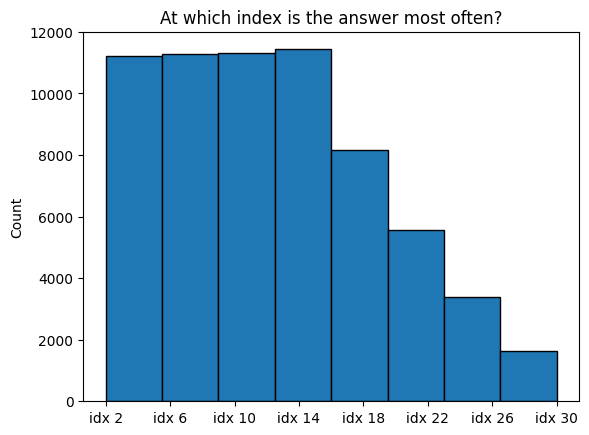

In [33]:
show_distr(train_df)

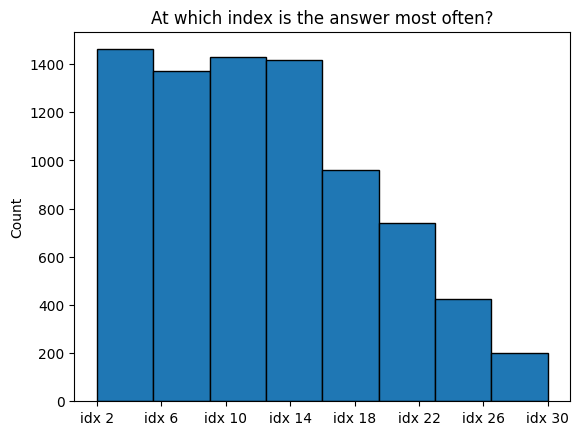

In [34]:
show_distr(val_df)

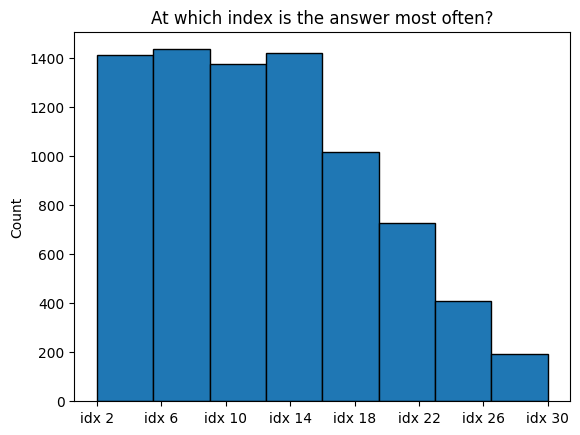

In [35]:
show_distr(test_df)

In [36]:
## So now lets pertube a lot of examples - and see which index the model predcits, when there is no matching entity-relation pair

In [37]:
test_dataset[0]

(tensor([ 94, 201, 118, 210,  43, 208, 105, 210,  18, 200, 155, 210,  95, 204,
         144, 210,  48, 202, 106, 210,  37, 205, 111, 210,  54, 206, 169, 210,
          80, 207, 154, 210, 208,  43, 211]),
 tensor(105))

In [38]:
# Gets all of the facts and the query of an example
def parse_facts(seq, SEP_token=SEP):
    seps = [i for i,t in enumerate(seq) if t == SEP_token]
    facts = [tuple(seq[i-3:i]) for i in seps]  # [(E,T,A), ...]
    Tq, Eq, _Q = seq[seps[-1]+1:seps[-1]+4]
    return facts, (Eq, Tq), seps

In [61]:
rng = np.random.default_rng(0)

def corrupt_query(seq):
    seq_list = seq.tolist()
    facts, (Eq, Tq), seps = parse_facts(seq_list, SEP)

    # get all of the entities that are in this specific context, and all of the types and then pick
    # a random one that replaces each, that is NOT present in the context
    present_entities = {e for (e, t, a) in facts}
    present_types    = {t for (e, t, a) in facts}

    not_present_entities = [e for e in range(0,100) if e not in present_entities]
    not_present_types    = [t for t in range(200,210) if t not in present_types]

    Eq_new = rng.choice(not_present_entities)
    Tq_new = rng.choice(not_present_types)

    q_start = seps[-1] + 1 # using last separator token
    seq_list[q_start]   = Tq_new
    seq_list[q_start+1] = Eq_new
    return seq_list

In [51]:
df2 = pd.read_csv('id_mapping.csv')
mapping = dict(zip(df2['id'], df2['name']))

In [46]:
example, label = test_dataset[0]
example, label

(tensor([ 94, 201, 118, 210,  43, 208, 105, 210,  18, 200, 155, 210,  95, 204,
         144, 210,  48, 202, 106, 210,  37, 205, 111, 210,  54, 206, 169, 210,
          80, 207, 154, 210, 208,  43, 211]),
 tensor(105))

In [57]:
q = example.tolist()
q_new = [mapping[i] if i in mapping else i for i in q]
print(q_new)

['Bryan', 'was born in', 'Istanbul', 210, 'Keith', 'moved to', 'Manila', 210, 'Lisa', 'lives in', 'Philadelphia', 210, 'Patrick', 'studied in', 'Riyadh', 210, 'Cynthia', 'works in', 'Shanghai', 210, 'Christine', 'married in', 'Sao Paulo', 210, 'Deborah', 'visited', 'Cape Town', 210, 'Anna', 'loves', 'Miami', 210, 'moved to', 'Keith', 211]


In [47]:
seq_corrupt = corrupt_query(example)

32


In [58]:
q_new = [mapping[i] if i in mapping else i for i in seq_corrupt]
print(q_new)

['Bryan', 'was born in', 'Istanbul', 210, 'Keith', 'moved to', 'Manila', 210, 'Lisa', 'lives in', 'Philadelphia', 210, 'Patrick', 'studied in', 'Riyadh', 210, 'Cynthia', 'works in', 'Shanghai', 210, 'Christine', 'married in', 'Sao Paulo', 210, 'Deborah', 'visited', 'Cape Town', 210, 'Anna', 'loves', 'Miami', 210, 'left', 'Reginald', 211]


In [59]:
## OK - lets do this over the whole dataset

In [62]:
seq_corrupted = []
for i in range(len(test_dataset)):
    example, label = test_dataset[i]
    seq_corrupted.append(corrupt_query(example))

In [70]:
from tqdm import tqdm
positions = []
with torch.no_grad():
  for seq in tqdm(seq_corrupted):
    logits = model(torch.tensor(seq))
    positions.append(seq.index(logits[0, -1, :].argmax()))

100%|██████████| 8000/8000 [00:28<00:00, 280.62it/s]


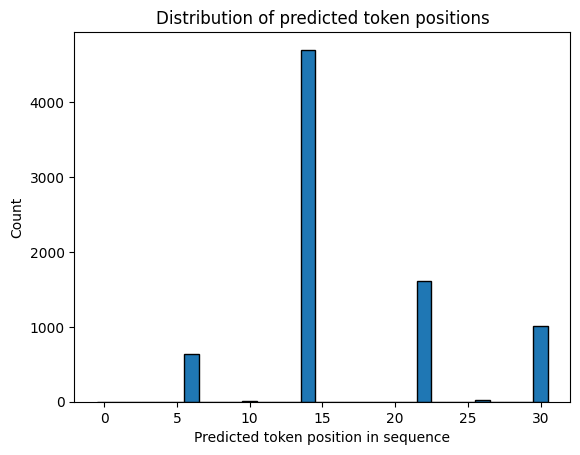

In [71]:
plt.hist(positions, bins=range(0, max(positions)+2), edgecolor="black", align="left")
plt.xlabel("Predicted token position in sequence")
plt.ylabel("Count")
plt.title("Distribution of predicted token positions")
plt.show()